# Final Model with Interaction
## Setup Jupyter Notebook
### Import Packages

In [109]:
# Import external packages
import pandas as pd
import os
import numpy as np
import random
import pyarrow.parquet as pq
import sys
import shutil
import pickle
import warnings
from itertools import chain

from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_percentage_error

from pygam import GAM, s, te, f, l

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import LogLocator
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from src.colours import red_blue

import optuna
from optuna.visualization import matplotlib as optunampl

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 260)
warnings.filterwarnings("ignore")

In [2]:
# Import the internal package
package_loc = r"../"

# Add the package location to system paths
sys.path.append(package_loc)

from src import utils
from src.gam import training, explain

### Define Paths

In [77]:
###########################################################################
###########################################################################

data_version = "v2"
model_version = "v3"

###########################################################################
###########################################################################

# Define the directories for input and output
dir_input = f"input"
dir_data = f"export"
dir_output = f"output"

modelling_log_03 = f"{dir_output}/03_model_note_{model_version}.xlsx"
modelling_log_04 = f"{dir_output}/04_model_note_{model_version}.xlsx"
modelling_log_05 = f"{dir_output}/05_model_note_{model_version}.xlsx"

model_data_file = f"{dir_data}/gam_modelling_data_{data_version}.parquet"
model_final_filename = f"{dir_output}/gam_final_{model_version}.pkl"
final_inter_rating_table_output = f"output/final_inter_rating_tables{model_version}.pkl"
ypred_sf_filename = f"export/gam_sf_pred_{model_version}.parquet"

print(os.listdir(dir_input))
print(os.listdir(dir_data))
print(os.listdir(dir_output))

['.gitkeep', 'CMI TA DB 2016 Datasheet v02 2024-06-17.xlsb', 'CMI TA DB 2017 Datasheet v02 2024-06-17.xlsb', 'CMI TA DB 2018 Datasheet v01 2022-05-20.xlsb', 'CMI TA DB 2019 Datasheet v01 2022-05-20.xlsb', 'CMI TA DB 2020 Datasheet v01 2022-05-20.xlsb']
['CMI Categorical Bands (with CalendarYear).xlsx', 'gam_modelling_data_v2.parquet', 'gam_sf_pred_v3.parquet']
['02_model_note_v3.xlsx', '03_model_note_v3.xlsx', '04_model_note_v3.xlsx', '05_model_note_v3.xlsx', 'final_inter_rating_tablesv3.pkl', 'final_single_factor_rating_tables_v3.pkl', 'gam_final_v3.pkl', 'gam_initial_v3.pkl', 'gam_sf_v3.pkl', 'single_factor_rating_tables_v3.pkl', 'training_data_folds_v3.pkl']


### Set Variables

In [4]:
title_fontsize = 25
label_fontsize = 20
ticker_fontsize = 15

## Create Modelling Data
### Load in the pruning progress

In [5]:
###########################################################################
###########################################################################

factors_tab = "Factors_Used"
pruning_tab = "Prune_Progress"

###########################################################################
###########################################################################

# Import the factor tracking tab
factorstracking_df = pd.read_excel(f"{modelling_log_03}", factors_tab)
# Import the pruning progress tab
factor_prune_df = pd.read_excel(f"{modelling_log_03}", pruning_tab)

In [6]:
# Define the final set of features used in the model
iter_num = factor_prune_df.loc[
    (factor_prune_df["bic_poisson"] == factor_prune_df["bic_poisson"].min()), "iter"
].values[0]
final_feature = factorstracking_df.iloc[iter_num]
final_feature = final_feature.dropna().tolist()

# Include calandar year if not already in the final features - important for Covid
if "CalendarYear" not in final_feature:
    final_feature += ["CalendarYear"]
print(final_feature)

['Age', 'SmokerStatus', 'Duration', 'Gender', 'SumAssuredBand', 'CalendarYear']


### Import modelling data

In [ ]:
model_data = pd.read_parquet(f"{model_data_file}")
model_data

In [8]:
###########################################################################
###########################################################################

claim_count = "IncurredClaims"
claim_freq = "AnnualFreq"
weight = "LivesExposure"

# Define the list of numerical features
num_feat = [
    "SumAssuredBand",
    "Age",
    "Duration",
]

# Define the list of categorical features
cat_feat = [
    "ProductCategory_cat_level",
    "Gender_cat_level",
    "SmokerStatus_cat_level",
    "DistributionChannel_cat_level",
    "JointLifeStatus_cat_level",
    "CalendarYear_cat_level",
]

###########################################################################
###########################################################################

# Define the target for GAM
model_data[claim_freq] = model_data[claim_count] / model_data[weight]

num_feat_final = [x for x in num_feat if x in final_feature]
cat_feat_final = [
    x for x in cat_feat if x.replace("_cat_level", "") in final_feature
]

# Define the full feature list
all_feat_final = num_feat_final + cat_feat_final
print(all_feat_final)

['SumAssuredBand', 'Age', 'Duration', 'Gender_cat_level', 'SmokerStatus_cat_level', 'CalendarYear_cat_level']


In [9]:
# Check the number of rows with null target
print(model_data[model_data[claim_freq].isnull()].shape[0])

1192


In [ ]:
# Null values in the target are caused by zero exposure in the data
model_data[model_data[claim_freq].isnull()].head()

In [ ]:
# Need to remove rows with 0 exposures
model_data = model_data[
    ~((model_data[claim_freq].isnull()) | (model_data[claim_freq] == np.inf))
]
model_data

In [12]:
# Count null values for all columns
model_data.isnull().sum()

ProductCategory                  0
Gender                           0
SmokerStatus                     0
DistributionChannel              0
CommencementYear                 0
JointLifeStatus                  0
SumAssuredBand                   0
Age                              0
Duration                         0
LivesExposure                    0
AmountsExposure                  0
IncurredClaims                   0
AmountIncurred                   0
ExpectedClaims                   0
ExpectedAmountClaims             0
ComparatorTable                  0
CalendarYear                     0
holdout                          0
random_fold                      0
ProductCategory_cat_level        0
Gender_cat_level                 0
SmokerStatus_cat_level           0
DistributionChannel_cat_level    0
JointLifeStatus_cat_level        0
CalendarYear_cat_level           0
AnnualFreq                       0
dtype: int64

### Define required dataframes

In [13]:
###########################################################################
###########################################################################

training_folds_files = f"{dir_output}/training_data_folds_{model_version}.pkl"

###########################################################################
###########################################################################

with open(f"{dir_output}/training_data_folds_{model_version}.pkl", "rb") as file:
    X_train_rs, y_train_rs, w_train_rs, folds, base_adj = pickle.load(file)

X_train_rs = X_train_rs[all_feat_final]

print(f"Base Adjustment: {base_adj:.4f}")

Base Adjustment: 0.7744


In [14]:
###########################################################################
###########################################################################

holdout = "holdout"
random_fold = "random_fold"
num_fold = 5  # Number of folds in the training data

###########################################################################
###########################################################################

X_train = model_data.loc[model_data[holdout] == 0, all_feat_final]
y_train = model_data.loc[model_data[holdout] == 0, claim_freq]
w_train = model_data.loc[model_data[holdout] == 0, weight]

X_test = model_data.loc[model_data[holdout] == 1, all_feat_final]
y_test = model_data.loc[model_data[holdout] == 1, claim_freq]
w_test = model_data.loc[model_data[holdout] == 1, weight]

In [15]:
# In any unseen data, any categorical level not in the training set will be mapped to the mode of the training set
for v in cat_feat_final:
    unique_level = X_train_rs[v].unique()
    condition = X_test[v].isin(unique_level)
    X_test[v] = np.where(condition, X_test[v], X_train_rs[v].mode().iloc[0])
X_test

,SumAssuredBand,Age,Duration,Gender_cat_level,SmokerStatus_cat_level,CalendarYear_cat_level
unique_id,,,,,,
5,5,39,10,0,0,0
6,5,44,10,0,0,0
16,4,51,10,0,0,0
26,5,53,10,0,0,0
38,5,43,10,0,0,0
...,...,...,...,...,...,...
2535416,3,29,0,1,1,4
2535420,3,33,0,1,1,4
2535428,3,41,0,1,1,4


## Final Model Training
### Define interaction terms

In [16]:
###########################################################################
###########################################################################

interaction_tab = "Inter_Imp_GBM"

###########################################################################
###########################################################################

interaction_imp = pd.read_excel(
    f"{modelling_log_05}", interaction_tab
)
interaction_imp["Feature1"] = (
    interaction_imp["Feature_List"].str.split(" x ").str[0]
)
interaction_imp["Feature1"] = interaction_imp["Feature1"].apply(
    lambda x: x if x in num_feat else x + "_cat_level" 
)
interaction_imp["Feature2"] = (
    interaction_imp["Feature_List"].str.split(" x ").str[1]
)
interaction_imp["Feature2"] = interaction_imp["Feature2"].apply(
    lambda x: x if x in num_feat else x + "_cat_level" 
)
interaction_imp["Feature_List1"] = interaction_imp.apply(
    lambda x: (x.Feature1, x.Feature2), axis=1
)
interaction_imp["Feature_List2"] = interaction_imp["Feature_List1"].apply(
    lambda x: " x ".join(x)
)

Text(0.5, 1.0, 'Interaction Importance')

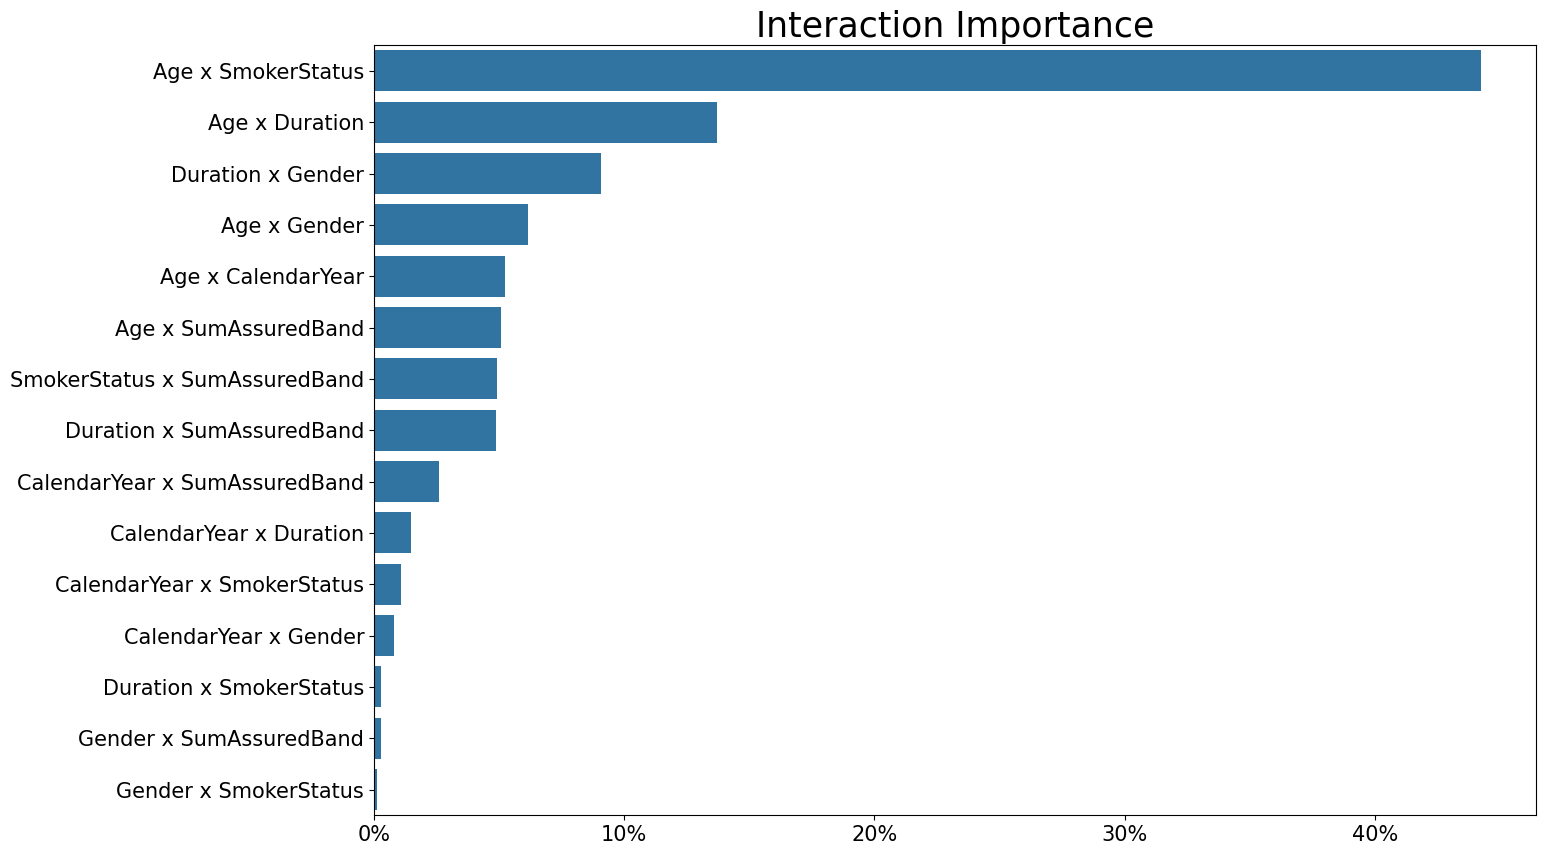

In [17]:
plt.rcParams["figure.figsize"] = (15, 10)
plt.rcParams["axes.edgecolor"] = "black"

fig, ax = plt.subplots(1)

sns.barplot(
    data=interaction_imp, 
    y="Feature_List", 
    x="Gain_Norm", 
    color="tab:blue", 
    ax=ax,
)

# Do some formating in the x and y axes to make them easier to read
xticker = ax.get_xticks() 
xlabel = [f'{x:,.0%}' for x in xticker]
ax.set_xticklabels(xlabel, fontsize=ticker_fontsize)

ylabel = interaction_imp["Feature_List"] 
ax.set_yticklabels(ylabel, fontsize=ticker_fontsize)

ax.set_facecolor("white")

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title("Interaction Importance", fontsize=title_fontsize)

In [18]:
############################################
############################################

# Define number of interaction terms included 
num_inter = 8

############################################
############################################

interaction_list = list(interaction_imp.loc[:num_inter, "Feature_List1"])
print(interaction_list)

[('Age', 'SmokerStatus_cat_level'), ('Age', 'Duration'), ('Duration', 'Gender_cat_level'), ('Age', 'Gender_cat_level'), ('Age', 'CalendarYear_cat_level'), ('Age', 'SumAssuredBand'), ('SmokerStatus_cat_level', 'SumAssuredBand'), ('Duration', 'SumAssuredBand'), ('CalendarYear_cat_level', 'SumAssuredBand')]


### Define GAM term structure

In [19]:
term_string, num_feat_map, cat_feat_map, inter_feat_map = (
    training.create_term_structure(
        num_feat_final, 
        cat_feat_final, 
        X_train_rs,
        interaction_list
    )
)
print(term_string)

s(0, lam=lam_num, n_splines=n_splines)+ s(1, lam=lam_num, n_splines=n_splines)+ s(2, lam=lam_num, n_splines=n_splines) + f(3, lam=lam_cat) + f(4, lam=lam_cat) + f(5, lam=lam_cat) + te(1, 4, lam=[lam_num_inter, lam_cat_inter], n_splines=[n_splines_inter, 4], constraints=[None, None], dtype=['numerical', 'categorical']) + te(1, 2, lam=[lam_num_inter, lam_num_inter], n_splines=[n_splines_inter, n_splines_inter], constraints=[None, None], dtype=['numerical', 'numerical']) + te(2, 3, lam=[lam_num_inter, lam_cat_inter], n_splines=[n_splines_inter, 4], constraints=[None, None], dtype=['numerical', 'categorical']) + te(1, 3, lam=[lam_num_inter, lam_cat_inter], n_splines=[n_splines_inter, 4], constraints=[None, None], dtype=['numerical', 'categorical']) + te(1, 5, lam=[lam_num_inter, lam_cat_inter], n_splines=[n_splines_inter, 5], constraints=[None, None], dtype=['numerical', 'categorical']) + te(1, 0, lam=[lam_num_inter, lam_num_inter], n_splines=[n_splines_inter, n_splines_inter], constraints

### Model training

In [20]:

study_df = pd.read_excel(f"{modelling_log_04}", "Final_Tune")
best_params = study_df.sort_values("value").filter(regex="params_").iloc[0].to_dict()
best_params = {k.replace("params_", ""): v for k, v in best_params.items()}

n_splines = int(best_params["n_splines"])
lam_num = best_params["lam_num"]
lam_cat = best_params["lam_cat"]
n_splines_inter = 5

# As a heuristic, set hyperparameters related to interactions to be the same as single factor's
lam_num_inter = lam_num
lam_cat_inter = lam_cat

print(f"{'n_splines':<18}: {n_splines}")
print(f"{'lam_num':<18}: {lam_num}")
print(f"{'lam_cat':<18}: {lam_cat}")
print(f"{'n_splines_inter':<18}: {n_splines_inter}")
print(f"{'lam_num_inter':<18}: {lam_num_inter}")
print(f"{'lam_cat_inter':<18}: {lam_cat_inter}")

n_splines         : 9
lam_num           : 1.235814043809596
lam_cat           : 45.47437702430798
n_splines_inter   : 5
lam_num_inter     : 1.235814043809596
lam_cat_inter     : 45.47437702430798


In [38]:
# Fit the GAM model
gam_final = GAM(
    eval(term_string),
    distribution="poisson",
    link="log",
).fit(X_train_rs, y_train_rs, weights=w_train_rs)

gam_final.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     44.6835
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                      1535099 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                                2.126
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6419
Feature Function                  Lam

In [ ]:
# Save the GAM model as a pickle file
with open(model_final_filename, "wb") as file:
    pickle.dump(gam_final, file)

### Derive associated relativities

In [21]:
# Re-load the GAM model
with open(model_final_filename, "rb") as file:
    gam_final = pickle.load(file)
gam_final.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     44.6835
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                      1535099 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                                2.126
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6419
Feature Function                  Lam

#### Numerical Variables

In [35]:
# Initilise an empty dictionary for numerical variables
num_rel_dict, intercept_adj_list0 = training.extract_gam_relativity_num(
    gam_final,
    X_train_rs,
    w_train_rs,
    num_feat_map,
    weight,
    intercept_adj_list=[],
)
# Check one set of relativities for a rating factor
num_rel_dict["Duration"]

,Duration,relativity,LivesExposure
0,0,0.472137,2.504579e+06
1,1,0.669213,2.274345e+06
2,2,0.815357,1.956081e+06
3,3,0.905454,1.771911e+06
4,4,0.954701,1.626020e+06
5,5,0.998271,1.447740e+06
6,6,1.069388,1.332483e+06
7,7,1.147888,1.218101e+06
8,8,1.195603,1.111779e+06
9,9,1.193172,1.011155e+06


#### Categorical Variables

In [36]:
###########################################################################
###########################################################################

# Define the directory for the categorical mapping spreadsheet
cat_map_table = f"{dir_data}/CMI Categorical Bands (with CalendarYear).xlsx"

###########################################################################
###########################################################################

cat_rel_dict, intercept_adj_list1 = training.extract_gam_relativity_cat(
    gam_final,
    X_train_rs,
    w_train_rs,
    cat_feat_map,
    weight,
    cat_map_table, 
    intercept_adj_list=intercept_adj_list0,
)
cat_rel_dict["Gender_cat_level"]

,Gender_cat_level,Gender,relativity,LivesExposure
0,0,F,0.850697,1.093854e+07
1,1,M,1.141746,1.152173e+07


#### Interaction Terms

In [37]:
inter_rel_dict, intercept_adj_list = training.extract_gam_relativity_inter(
    gam_final,
    X_train_rs,
    w_train_rs,
    inter_feat_map,
    weight,
    cat_map_table, 
    intercept_adj_list=intercept_adj_list1,
)
inter_rel_dict["Age x SmokerStatus_cat_level"].head()

,Age,SmokerStatus_cat_level,relativity,LivesExposure,SmokerStatus
0,18.0,0.0,1.086822,756.686818,N
1,18.0,1.0,0.912317,146.448432,S
2,19.0,0.0,1.085997,2442.126671,N
3,19.0,1.0,0.912949,517.113452,S
4,20.0,0.0,1.084941,5228.652946,N


#### Adjust Intercept Term

In [71]:
assert len(intercept_adj_list) == len(
    all_feat_final + interaction_list
), "# intercept multipliers is not equal to # terms in GAM. Please check!!"

# Perform the adjustment
intercept = np.exp(gam_final.coef_[-1])
intercept_final = intercept * np.prod(intercept_adj_list) * base_adj

utils.pretty_print("Intercept Values")
print(f"{'Original':<10}: {intercept:,.5%}")
print(f"{'Adjusted':<10}: {intercept_final:,.5%}")

----------------
Intercept Values
----------------
Original  : 2.12413%
Adjusted  : 0.10816%


#### Export Intercept and Relativities

In [72]:
# Define the output
rating_tables = (intercept_final, num_rel_dict, cat_rel_dict, inter_rel_dict)
# Save
with open(final_inter_rating_table_output, "wb") as file:
    pickle.dump(rating_tables, file)

#### Control Testing

In [ ]:
###########################################################################
###########################################################################

new_model_freq = "gam_inter_freq"
cmi_base = "ExpectedClaims"
cmi_freq = "cmi_freq"
new_model_count = "gam_inter_claim_count"

###########################################################################
###########################################################################

# Re-load the rating table outputs
with open(final_inter_rating_table_output, "rb") as file:
    intercept_final, num_rel_dict, cat_rel_dict, inter_rel_dict = pickle.load(file)

# Define a dataframe that contains predictions, target and weight
ypred_test = gam_final.predict(X_test) * base_adj

ypred_test_df = pd.DataFrame(ypred_test, columns=[new_model_freq], index=X_test.index)
ypred_test_df = (
    ypred_test_df.join(y_test)
    .join(w_test)
    .join(
        model_data[
            [
                claim_count,
                cmi_base,
            ]
        ]
    )
)
ypred_test_df[new_model_count] = ypred_test_df[new_model_freq] * ypred_test_df[weight]
ypred_test_df[cmi_freq] = ypred_test_df[cmi_base] / ypred_test_df[weight]
ypred_test_df

In [76]:
###############################################################
###############################################################

# Define the number of decimal places to round the predictions
rounding_num = 7

###############################################################
###############################################################

# Test on the training ata
ypred_train = gam_final.predict(X_train_rs) * base_adj

# Define a procedure to score a dataset using the relativities extracted
X_train_rel = X_train_rs.copy()
rel_list = []

for v, r in num_rel_dict.items():
    X_train_rel[v + "_rel"] = X_train_rel[v].map(r.set_index(v)["relativity"].to_dict())
    rel_list.append(v + "_rel")

for v, r in cat_rel_dict.items():
    X_train_rel[v.replace("_cat_level", "") + "_rel"] = X_train_rel[v].map(
        r.set_index(v)["relativity"].to_dict()
    )
    rel_list.append(v.replace("_cat_level", "") + "_rel")

for v, r in inter_rel_dict.items():
    v1, v2 = v.split(" x ")
    v1_clean = v1.replace("_cat_level", "")
    v2_clean = v2.replace("_cat_level", "")
    ineraction_name = v1_clean + "_x_" + v2_clean + "_rel"
    r.rename(columns={"relativity": ineraction_name}, inplace=True)

    X_train_rel = X_train_rel.merge(
        r[[v1, v2, ineraction_name]], on=[v1, v2], how="left"
    )
    rel_list.append(ineraction_name)

# Reset index
X_train_rel.index = X_train_rs.index

# Check there are no null values
assert (
    X_train_rel.isnull().sum().sum() == 0
), "There are NA values in relativities calculated. Please check!!"

ypred_train_df = pd.DataFrame(
    ypred_train, columns=[new_model_freq], index=X_train_rs.index
)

ypred_train_df[f"{new_model_freq}_rel"] = (
    X_train_rel[rel_list].prod(axis=1) * intercept_final
)

check_df = ypred_train_df[
    ypred_train_df[new_model_freq].round(rounding_num)
    != ypred_train_df[f"{new_model_freq}_rel"].round(rounding_num)
]

# Check if there is any diff between the predictions from model and the predictions from rating tables
assert (
    len(check_df) == 0
), "There are differences detected between the model predictions and the predictions from rating tables. Please check!!"

### Holdout Assessment

In [79]:
###########################################################################
###########################################################################


sing_pred_count = "gam_claim_count"

###########################################################################
###########################################################################

# Import single factor predictions 
ypred_sing_df = pd.read_parquet(f"{ypred_sf_filename}")
ypred_sing_df[sing_pred_count] *= base_adj

ypred_test_df = ypred_test_df.join(ypred_sing_df[sing_pred_count])
ypred_test_df

,gam_inter_freq,AnnualFreq,LivesExposure,IncurredClaims,ExpectedClaims,gam_inter_claim_count,cmi_freq,gam_claim_count
unique_id,,,,,,,,
5,0.000335,0.0,0.538251,0.0,0.000187,0.000181,0.000347,0.000156
6,0.000496,0.0,0.426230,0.0,0.000231,0.000211,0.000542,0.000186
16,0.000960,0.0,0.002732,0.0,0.000003,0.000003,0.001012,0.000002
26,0.001083,0.0,0.248634,0.0,0.000299,0.000269,0.001201,0.000241
38,0.000457,0.0,0.658470,0.0,0.000326,0.000301,0.000495,0.000264
...,...,...,...,...,...,...,...,...
2535416,0.000220,0.0,0.814208,0.0,0.000125,0.000179,0.000154,0.000197
2535420,0.000266,0.0,2.472678,0.0,0.000502,0.000657,0.000203,0.000708
2535428,0.000492,0.0,2.189071,0.0,0.000919,0.001077,0.000420,0.001097


In [82]:
# Poisson Deviance
gam_dev = utils.total_poisson_dev(
    y=ypred_test_df[claim_count],
    y_pred=ypred_test_df[new_model_count],
)
gam_dev_sf = utils.total_poisson_dev(
    y=ypred_test_df[claim_count],
    y_pred=ypred_test_df[sing_pred_count],
)
cmi_dev = utils.total_poisson_dev(
    y=ypred_test_df[claim_count],
    y_pred=ypred_test_df[cmi_base],
)

utils.pretty_print("Total Poisson Deviance")
print(f"{'GAM Model (Final)':<20}: {gam_dev:,.0f}")
print(f"{'GAM Model (SF)':<20}: {gam_dev_sf:,.0f}")
print(f"{'CMI Base':<20}: {cmi_dev:,.0f}")

----------------------
Total Poisson Deviance
----------------------
GAM Model (Final)   : 52,873
GAM Model (SF)      : 52,929
CMI Base            : 52,946


In [88]:
################################################################
################################################################

# Define the list of new to current model prediction column names
predict = [new_model_count, sing_pred_count]

################################################################
################################################################

d = utils.DoubleLift(
    ypred_test_df, predict, claim_count, weight, [0.01, 0.99], approx_num_band=20
)

mape_gam = mean_absolute_percentage_error(
    d.double_lift_table[claim_count],
    d.double_lift_table[predict[0]],
    sample_weight=d.double_lift_table[weight],
)
mape_expected = mean_absolute_percentage_error(
    d.double_lift_table[claim_count],
    d.double_lift_table[predict[1]],
    sample_weight=d.double_lift_table[weight],
)
print(f"{'MAPE - GAM (Final)':<30}: {mape_gam:.2%}")
print(f"{'MAPE - GAM (SF)':<30}: {mape_expected:.2%}")

d.double_lift_table

MAPE - GAM (Final)            : 3.27%
MAPE - GAM (SF)               : 6.09%


,ratio_band,IncurredClaims,gam_inter_claim_count,gam_claim_count,LivesExposure
band,,,,,
1,"(0.506, 0.85]",0.000768,0.000847,0.001044,1.849814e+05
2,"(0.85, 0.9]",0.001281,0.001431,0.001628,2.183098e+05
3,"(0.9, 0.95]",0.001778,0.001875,0.002010,5.840140e+05
4,"(0.95, 1.0]",0.001876,0.001798,0.001843,1.692732e+06
5,"(1.0, 1.05]",0.001140,0.001162,0.001136,2.446955e+06
6,"(1.05, 1.1]",0.001009,0.000993,0.000927,1.453887e+06
7,"(1.1, 1.15]",0.000902,0.000882,0.000788,5.445659e+05
8,"(1.15, 1.41]",0.001121,0.001193,0.000985,1.184127e+05


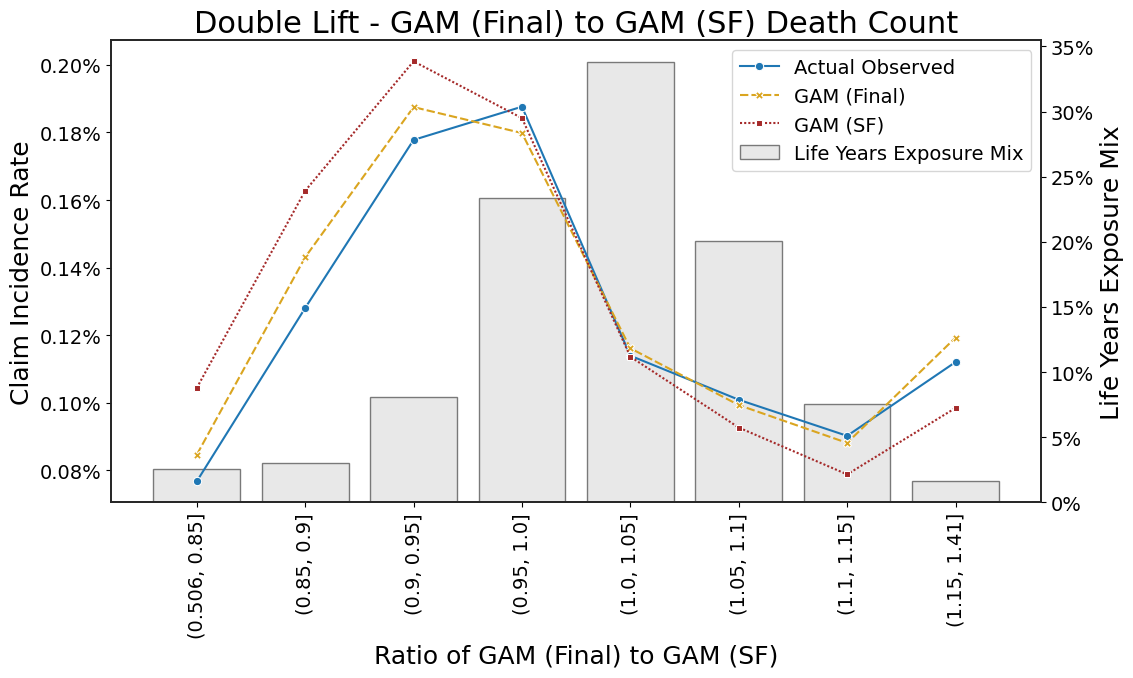

In [89]:
###########################################################################
###########################################################################

param_dict = {
    "title": "Double Lift - GAM (Final) to GAM (SF) Death Count", 
    "leftylabel": "Claim Incidence Rate", 
    "rightylabel": "Life Years Exposure Mix",
    "target_legend": "Actual Observed", 
    "new_model_legend": "GAM (Final)",
    "baseline_legend": "GAM (SF)",
    "palette": ["tab:blue", "#DAA520", "#A52A2A"]
}

###########################################################################
###########################################################################

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

fig, ax = plt.subplots(figsize=(12, 6))

d.plot_double_lift(ax=ax, **param_dict)

In [92]:
################################################################
################################################################

# Define the list of new to current model prediction column names
predict = [new_model_count, cmi_base]

################################################################
################################################################

d = utils.DoubleLift(
    ypred_test_df, predict, claim_count, weight, [0.01, 0.98], approx_num_band=15
)

mape_gam = mean_absolute_percentage_error(
    d.double_lift_table[claim_count],
    d.double_lift_table[predict[0]],
    sample_weight=d.double_lift_table[weight],
)
mape_expected = mean_absolute_percentage_error(
    d.double_lift_table[claim_count],
    d.double_lift_table[predict[1]],
    sample_weight=d.double_lift_table[weight],
)
print(f"{'MAPE - GAM (Final)':<30}: {mape_gam:.2%}")
print(f"{'MAPE - CMI':<30}: {mape_expected:.2%}")

d.double_lift_table

MAPE - GAM (Final)            : 4.84%
MAPE - CMI                    : 9.68%


,ratio_band,IncurredClaims,gam_inter_claim_count,ExpectedClaims,LivesExposure
band,,,,,
1,"(0.307, 0.8]",0.000853,0.000838,0.001139,5.227846e+05
2,"(0.8, 0.9]",0.001145,0.001100,0.001283,1.069272e+06
3,"(0.9, 1.0]",0.001383,0.001373,0.001438,2.063629e+06
4,"(1.0, 1.1]",0.001598,0.001546,0.001479,1.821040e+06
5,"(1.1, 1.2]",0.001361,0.001440,0.001260,9.708687e+05
6,"(1.2, 1.3]",0.001235,0.001331,0.001073,4.317390e+05
7,"(1.3, 1.4]",0.000950,0.001169,0.000870,1.684155e+05
8,"(1.4, 1.5]",0.000612,0.000627,0.000436,7.616862e+04
9,"(1.5, 1.6]",0.000236,0.000434,0.000282,3.970388e+04


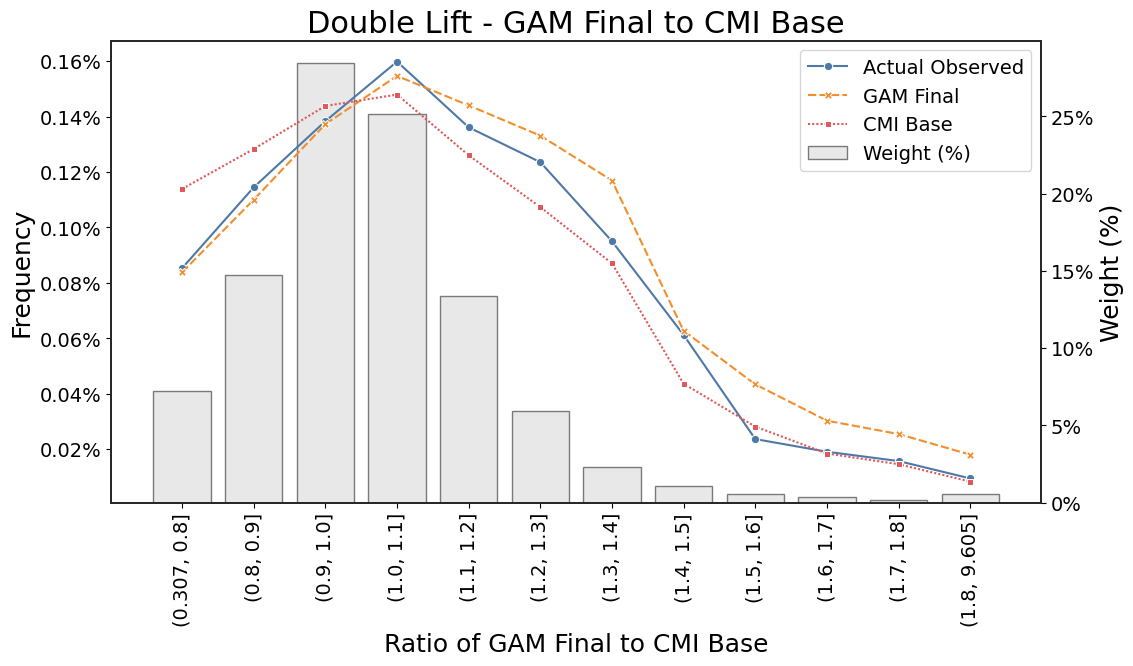

In [93]:
###########################################################################
###########################################################################

param_dict = {
    "title": "Double Lift - GAM Final to CMI Base", 
    "leftylabel": "Frequency", 
    "rightylabel": "Weight (%)",
    "target_legend": "Actual Observed", 
    "new_model_legend": "GAM Final",
    "baseline_legend": "CMI Base",
}

###########################################################################
###########################################################################

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

fig, ax = plt.subplots(figsize=(12, 6))

d.plot_double_lift(ax=ax, **param_dict)

## Model Explanation 
### Factor Strength

In [94]:
inter_rel_dict2 = inter_rel_dict.copy()

for k, v in inter_rel_dict2.items():
    v1 = k.split(" x ")[0]
    v2 = k.split(" x ")[1]
    v1_clean = v1.replace("_cat_level", "")
    v2_clean = v2.replace("_cat_level", "")

    inter_rel_dict2[v1 + " x " + v2] = inter_rel_dict2[v1 + " x " + v2].rename(
        columns={v1_clean + "_x_" + v2_clean + "_rel": "relativity"}
    )

single_fact_df, interaction_df = explain.factor_strength(
    num_rel_dict,
    cat_rel_dict,
    inter_rel_dict=inter_rel_dict2,
    weight=weight,
)

In [120]:
# Update the interaction terms to string formats
interaction_df["interaction1"] = interaction_df.apply(
    lambda x: x.feature1 + " x " + x.feature2, axis=1
)
interaction_df["feature1_full"] = interaction_df.apply(
    lambda x: (
        x.feature1 if x.feature1_type == "numerical" else x.feature1 + "_cat_level"
    ),
    axis=1,
)
interaction_df["feature2_full"] = interaction_df.apply(
    lambda x: (
        x.feature2 if x.feature2_type == "numerical" else x.feature2 + "_cat_level"
    ),
    axis=1,
)
interaction_df["interaction2"] = interaction_df.apply(
    lambda x: x.feature1_full + " x " + x.feature2_full, axis=1
)
interaction_df

,interaction_term,feature1,feature2,feature1_type,feature2_type,factor_strength,interaction1,feature1_full,feature2_full,interaction2
0,"(Age, Duration)",Age,Duration,numerical,numerical,0.102416,Age x Duration,Age,Duration,Age x Duration
1,"(Age, SumAssuredBand)",Age,SumAssuredBand,numerical,numerical,0.081402,Age x SumAssuredBand,Age,SumAssuredBand,Age x SumAssuredBand
2,"(Duration, SumAssuredBand)",Duration,SumAssuredBand,numerical,numerical,0.058963,Duration x SumAssuredBand,Duration,SumAssuredBand,Duration x SumAssuredBand
3,"(Age, SmokerStatus)",Age,SmokerStatus,numerical,categorical,0.037905,Age x SmokerStatus,Age,SmokerStatus_cat_level,Age x SmokerStatus_cat_level
4,"(Duration, Gender)",Duration,Gender,numerical,categorical,0.029292,Duration x Gender,Duration,Gender_cat_level,Duration x Gender_cat_level
5,"(SmokerStatus, SumAssuredBand)",SmokerStatus,SumAssuredBand,categorical,numerical,0.020919,SmokerStatus x SumAssuredBand,SmokerStatus_cat_level,SumAssuredBand,SmokerStatus_cat_level x SumAssuredBand
6,"(Age, CalendarYear)",Age,CalendarYear,numerical,categorical,0.014773,Age x CalendarYear,Age,CalendarYear_cat_level,Age x CalendarYear_cat_level
7,"(CalendarYear, SumAssuredBand)",CalendarYear,SumAssuredBand,categorical,numerical,0.014603,CalendarYear x SumAssuredBand,CalendarYear_cat_level,SumAssuredBand,CalendarYear_cat_level x SumAssuredBand
8,"(Age, Gender)",Age,Gender,numerical,categorical,0.012676,Age x Gender,Age,Gender_cat_level,Age x Gender_cat_level


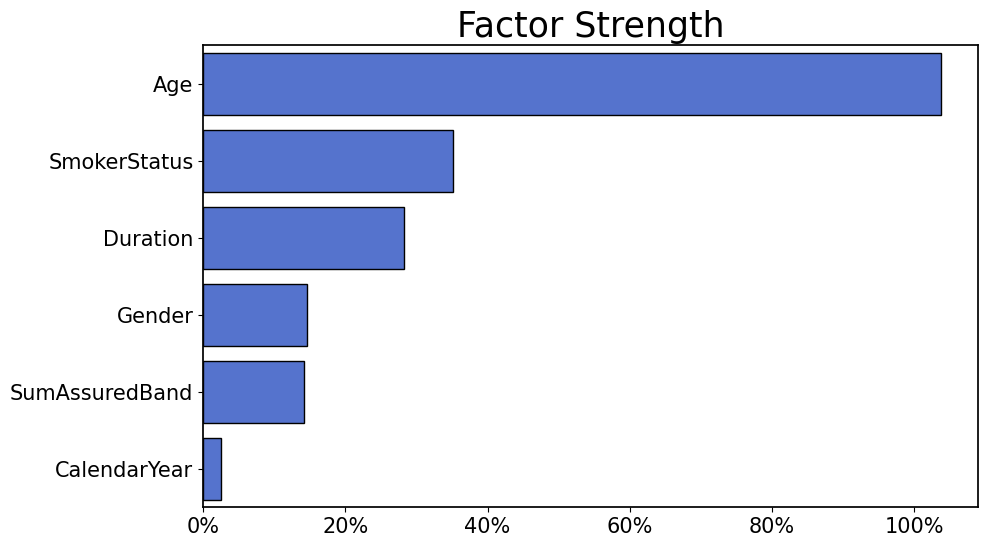

In [121]:
plt.rcParams["figure.figsize"] = [10, 6]
fig, ax = plt.subplots(1)
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.25

plot_df = single_fact_df.copy()
plot_df["feature"] = plot_df["feature"].str.replace("_ordinal", "")

# Plot data
sns.barplot(
    x="factor_strength",
    y="feature",
    data=plot_df,
    ax=ax,
    color="royalblue",
    edgecolor="black",
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
ax.set_title(f"Factor Strength", fontsize=title_fontsize)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

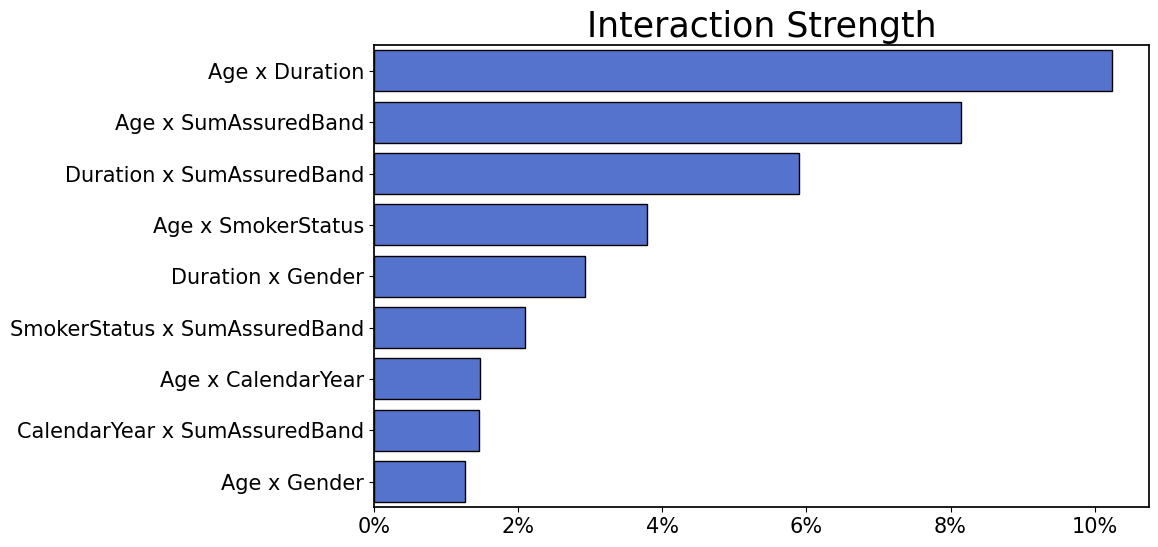

In [122]:
plt.rcParams["figure.figsize"] = [10, 6]
fig, ax = plt.subplots(1)
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.25

plot_df = interaction_df.copy()
plot_df["interaction1"] = plot_df["interaction1"].str.replace("_ordinal", "")

# Plot data
sns.barplot(
    x="factor_strength",
    y="interaction1",
    data=plot_df,
    ax=ax,
    color="royalblue",
    edgecolor="black",
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
ax.set_title(f"Interaction Strength", fontsize=title_fontsize)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

### Single Factor Trend Assessment

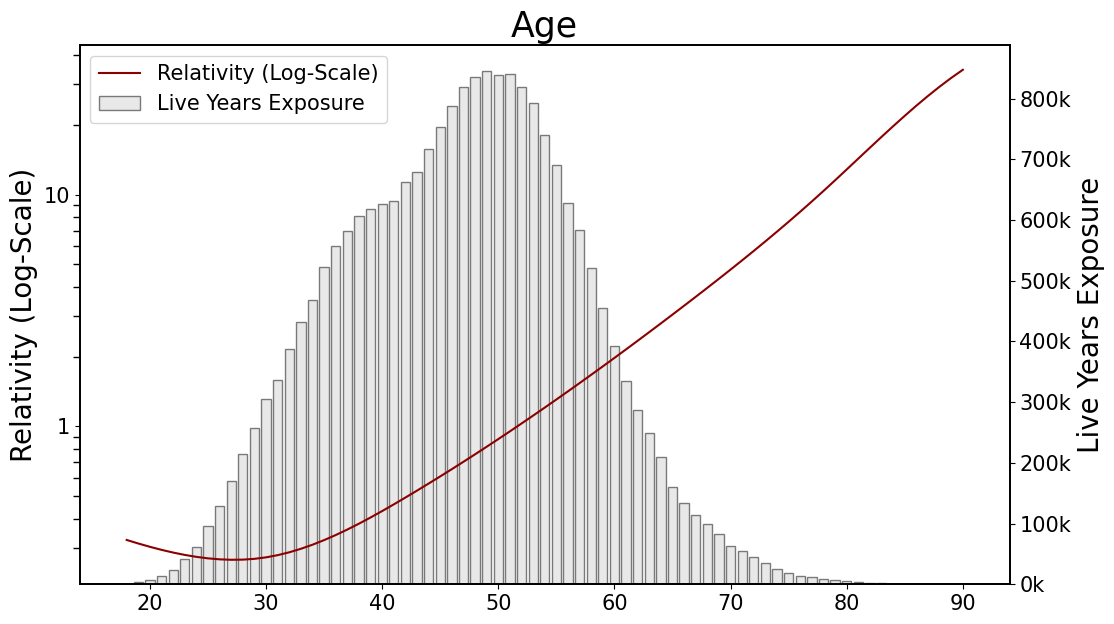

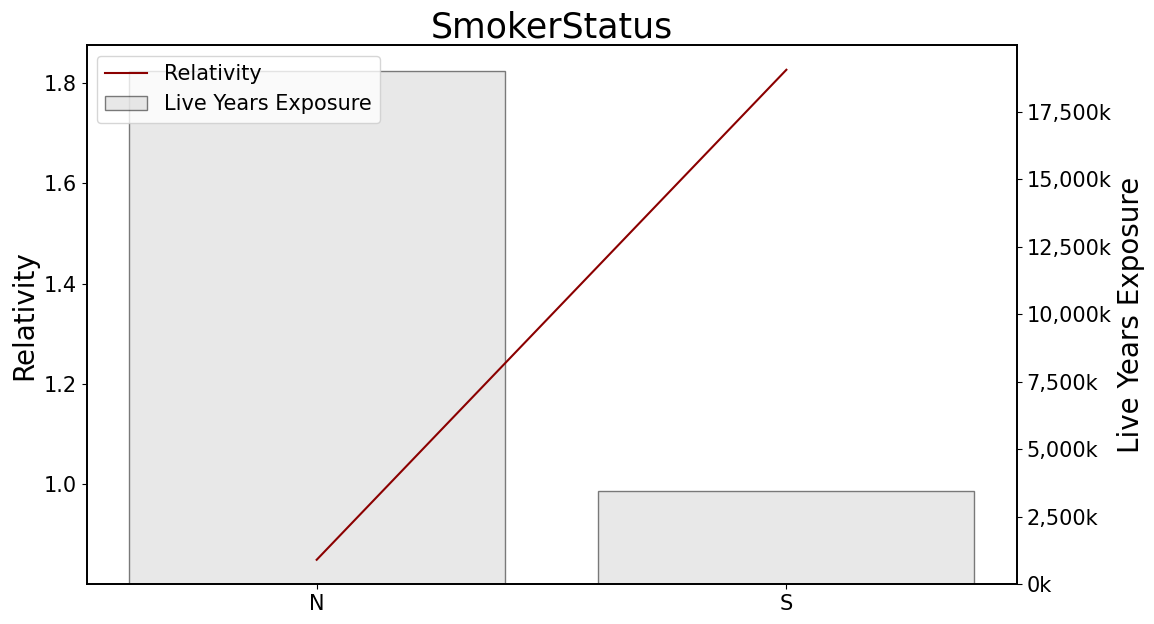

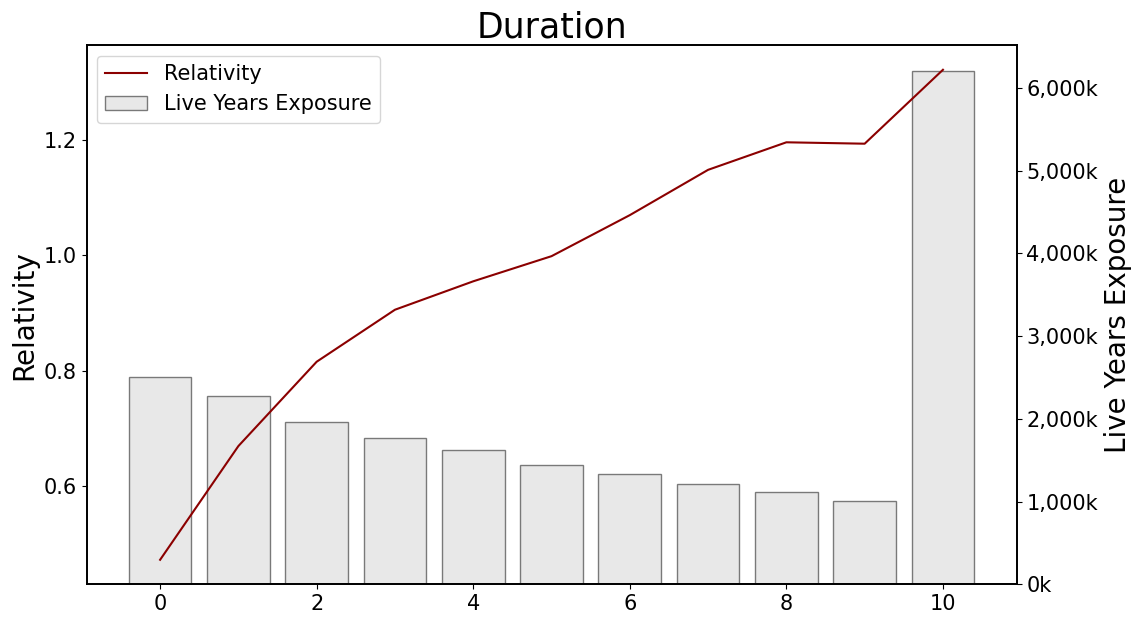

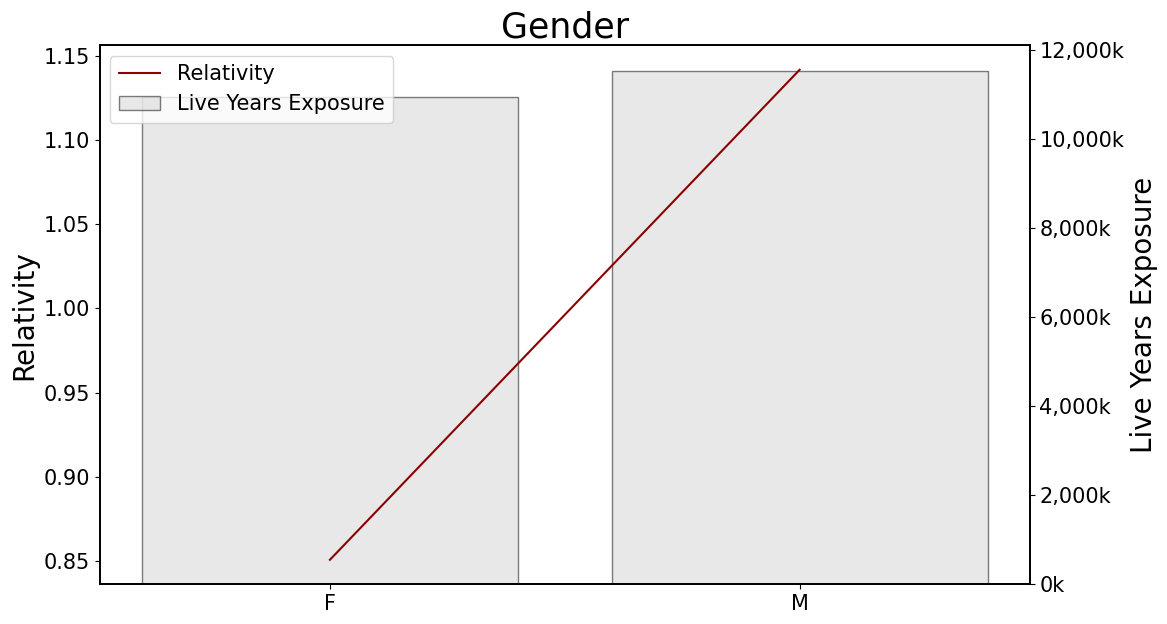

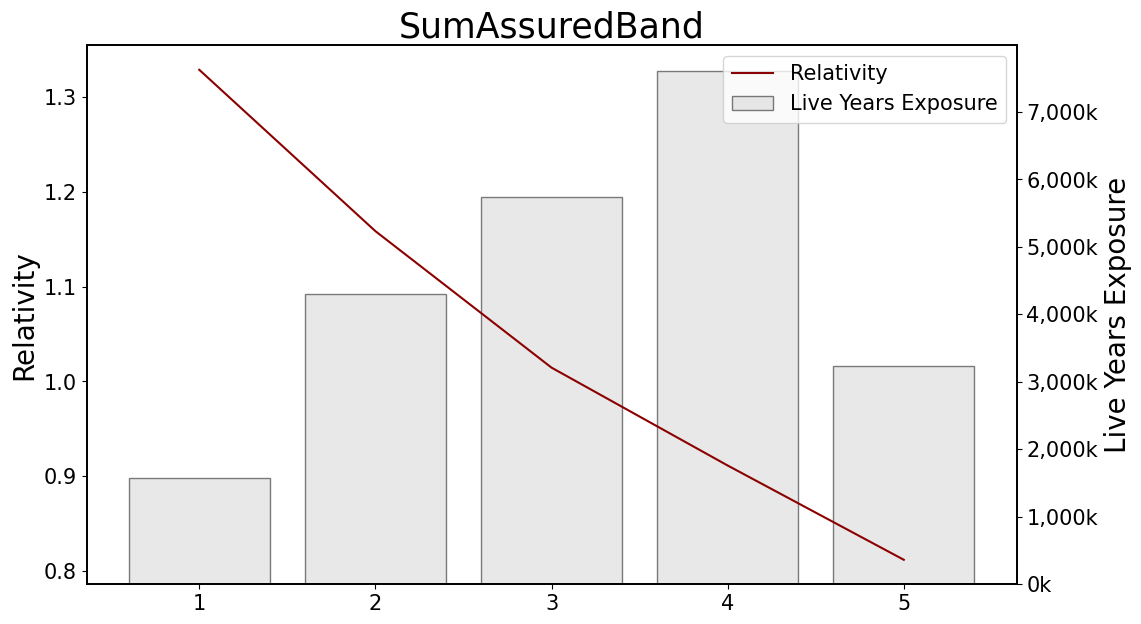

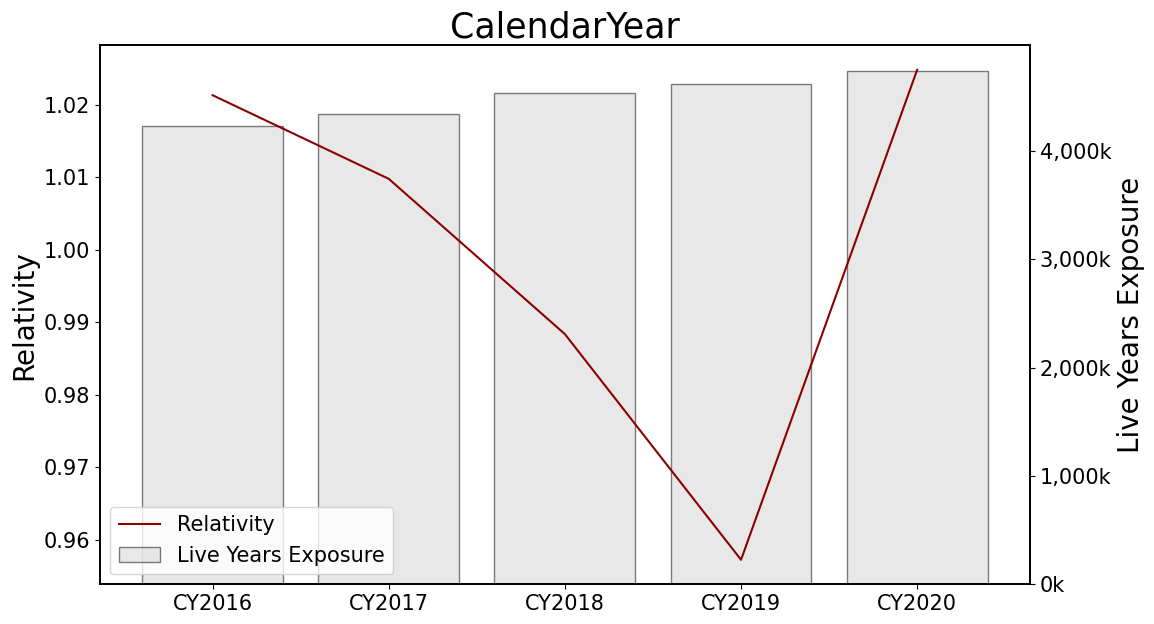

In [123]:
###################################################################
###################################################################

# Define the age variable
age_var = "Age"
rightylabel = "Live Years Exposure"
var_xtick_adj_list = []

###################################################################
###################################################################

for v in single_fact_df["feature"]:

    # Get the relativity table
    rel_table = (
        num_rel_dict[v] if v in num_rel_dict.keys() else cat_rel_dict[v + "_cat_level"]
    )
    rel_table = rel_table.set_index(v)
    # Start plotting
    fig, ax = plt.subplots(1, figsize=(12, 7))
    leftylabel = "Relativity (Log-Scale)" if v == age_var else "Relativity"

    sns.lineplot(data=rel_table["relativity"], ax=ax, color="darkred", label=leftylabel)

    ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
    ax.set_xlabel("")
    ax.set_ylabel(leftylabel, fontsize=label_fontsize)
    ax.set_title(v.replace("_ordinal", ""), fontsize=title_fontsize)

    if v == age_var:
        ax.set_yscale("log")

        # Set specific tick locations
        ax.yaxis.set_major_locator(mtick.FixedLocator([1, 10]))

        # Format labels
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: "{:g}".format(y)))

        # Add minor ticks for gridlines
        ax.yaxis.set_minor_locator(
            LogLocator(base=10, subs=np.arange(2, 10), numticks=10)
        )
        ax.tick_params(axis="y", which="minor", length=5, width=1, direction="out")

    ax.grid(False)

    ax2 = ax.twinx()
    ax2.bar(
        rel_table.index,
        rel_table[weight],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=rightylabel,
    )
    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=ticker_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=ticker_fontsize,
        facecolor="white",
    )
    # Set secondary y-axis label
    ax2.set_ylabel(rightylabel, fontsize=label_fontsize)

    if v in var_xtick_adj_list:
        xticks = rel_table.index.values
        if len(xticks) > 15:
            step = len(xticks) // 10
            xticks = xticks[::step]
        ax.set_xticks(xticks)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)

### Interaction Trends

In [124]:
for var, rel in inter_rel_dict2.items(): 
    var1, var2 = var.split(" x ")
    
    rel1 = (
        cat_rel_dict[var1] if "_cat_level" in var1 else num_rel_dict[var1]
    )
    rel2 = (
        cat_rel_dict[var2] if "_cat_level" in var2 else num_rel_dict[var2]
    )
    
    inter_rel_dict2[var]["var1_rel"] = inter_rel_dict2[var][var1].map(
        rel1.set_index(var1)["relativity"].to_dict()
    )
    inter_rel_dict2[var]["var2_rel"] = inter_rel_dict2[var][var2].map(
        rel2.set_index(var2)["relativity"].to_dict()
    )
    inter_rel_dict2[var]["combined_rel"] = (
        inter_rel_dict2[var]["relativity"]
        * inter_rel_dict2[var]["var1_rel"]
        * inter_rel_dict2[var]["var2_rel"]
    )

In [130]:
age_duration_table = inter_rel_dict2["Age x Duration"].copy()
age_duration_table["Duration"] = inter_rel_dict2["Age x Duration"][
    "Duration"
]
age_duration_table["combined_rel_weight"] = (
    age_duration_table["combined_rel"] * age_duration_table[weight]
)

age_duration_table["relativity_weight"] = (
    age_duration_table["relativity"] * age_duration_table[weight]
)
age_duration_table = age_duration_table.groupby(
    ["Age", "Duration"], as_index=False
)[["relativity_weight", "combined_rel_weight", weight]].sum()
age_duration_table["relativity"] = (
    age_duration_table["relativity_weight"] / age_duration_table[weight]
)
age_duration_table["combined_rel"] = (
    age_duration_table["combined_rel_weight"] / age_duration_table[weight]
)
inter_rel_dict2["Age x Duration"] = age_duration_table

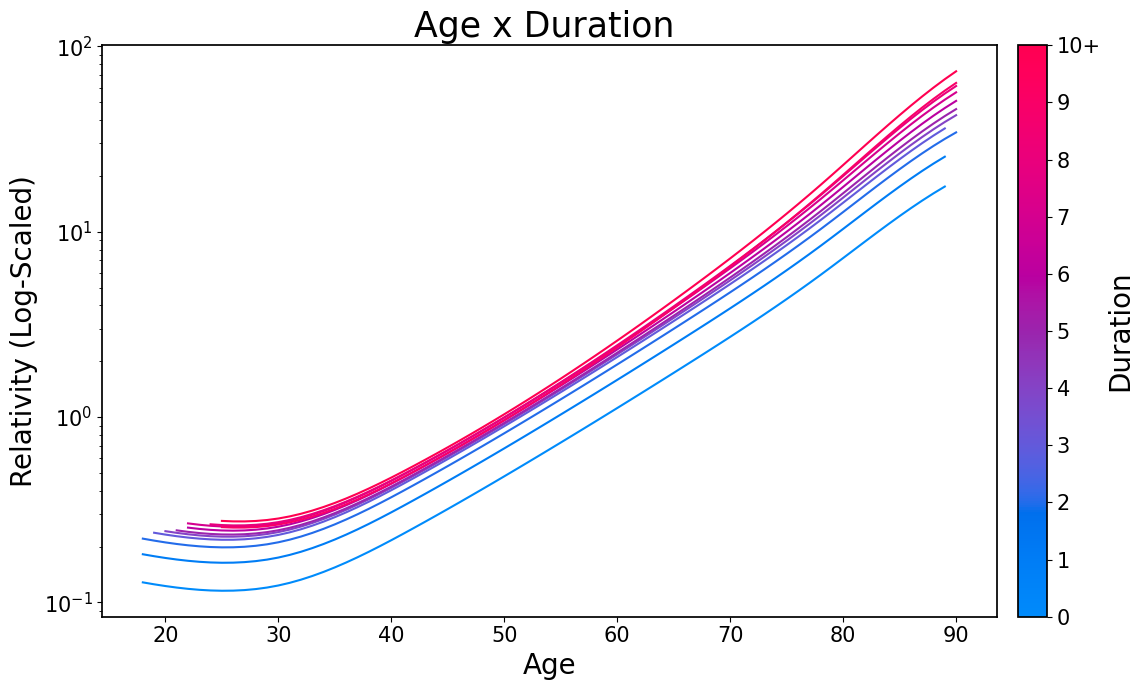

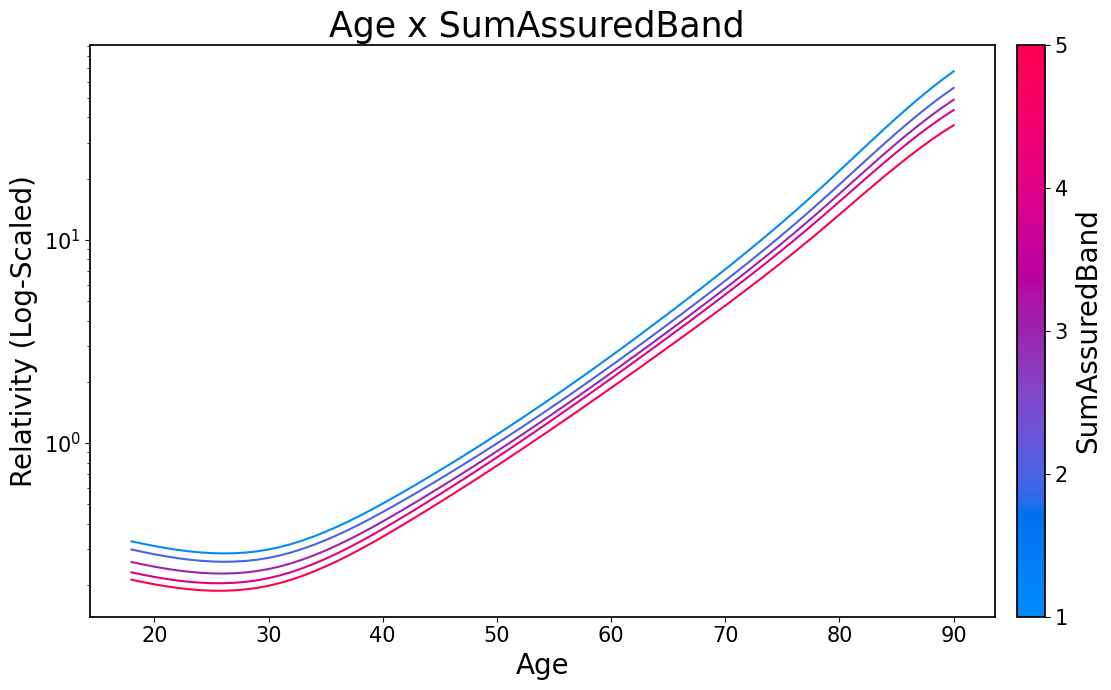

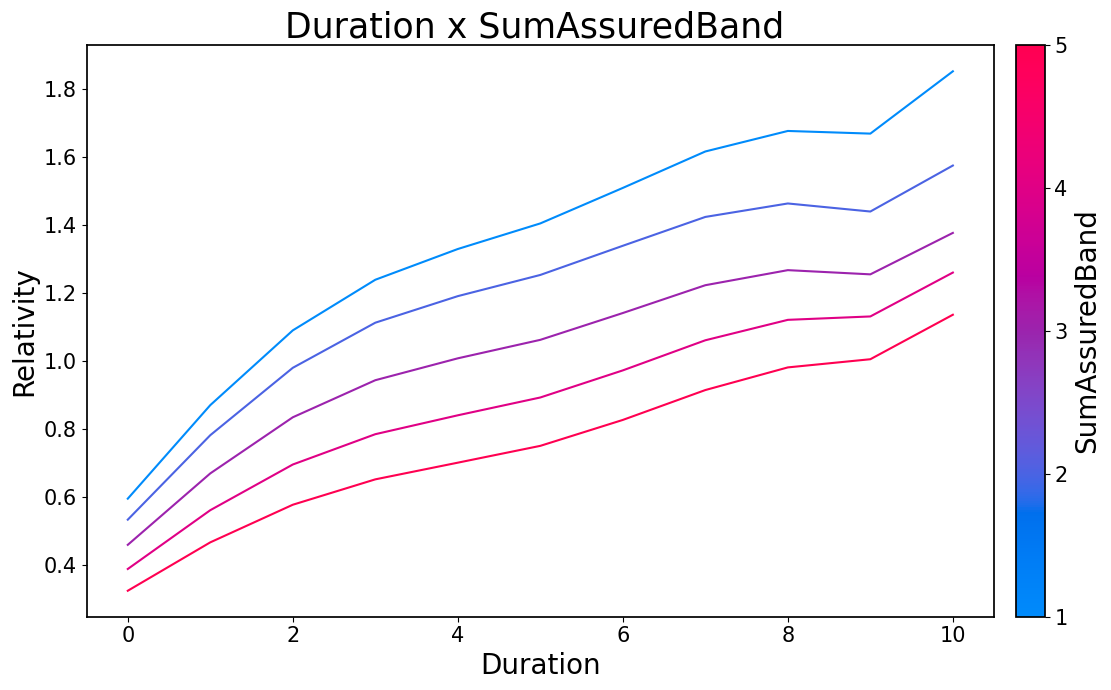

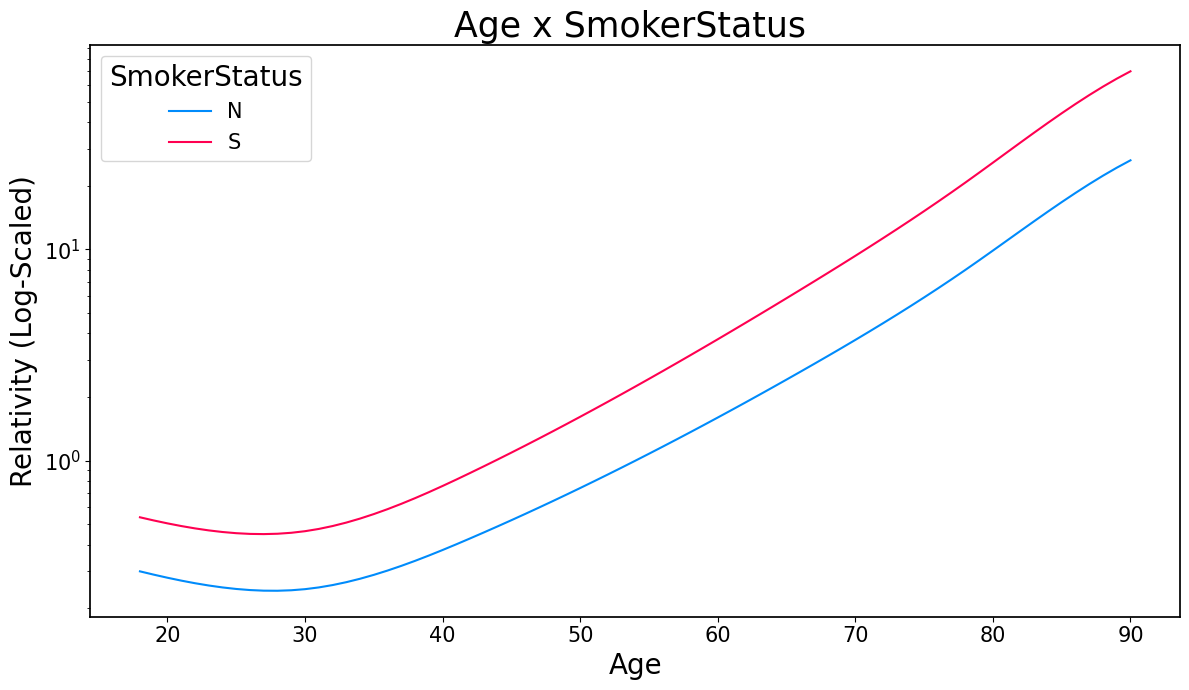

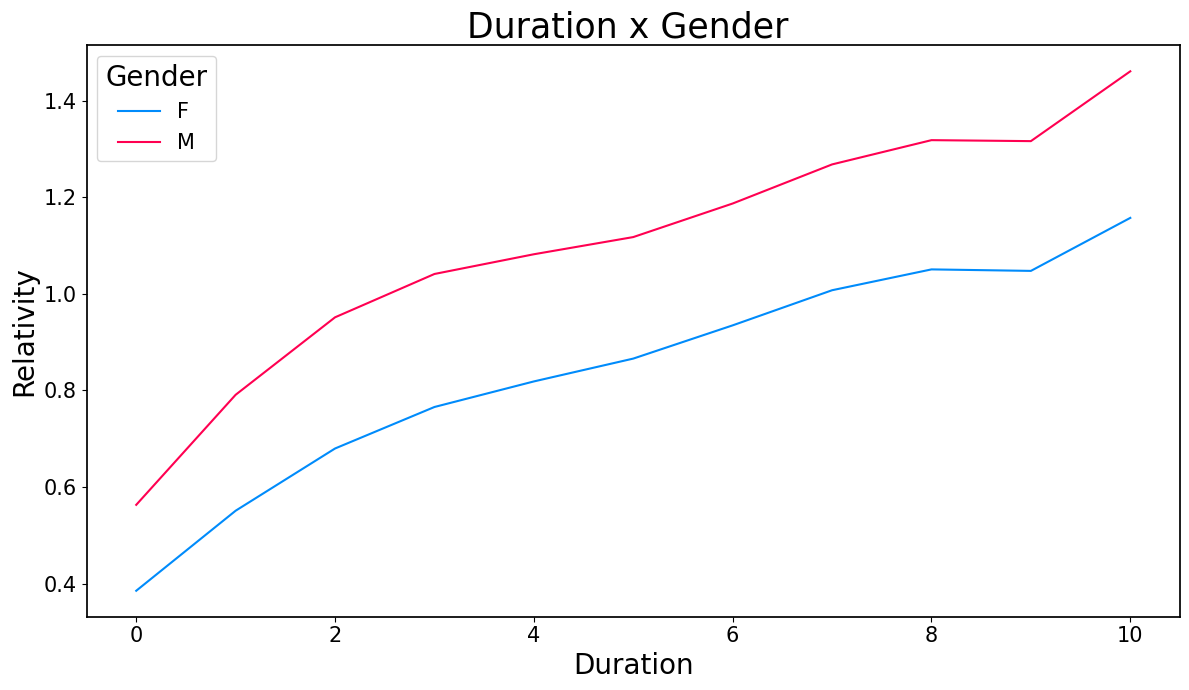

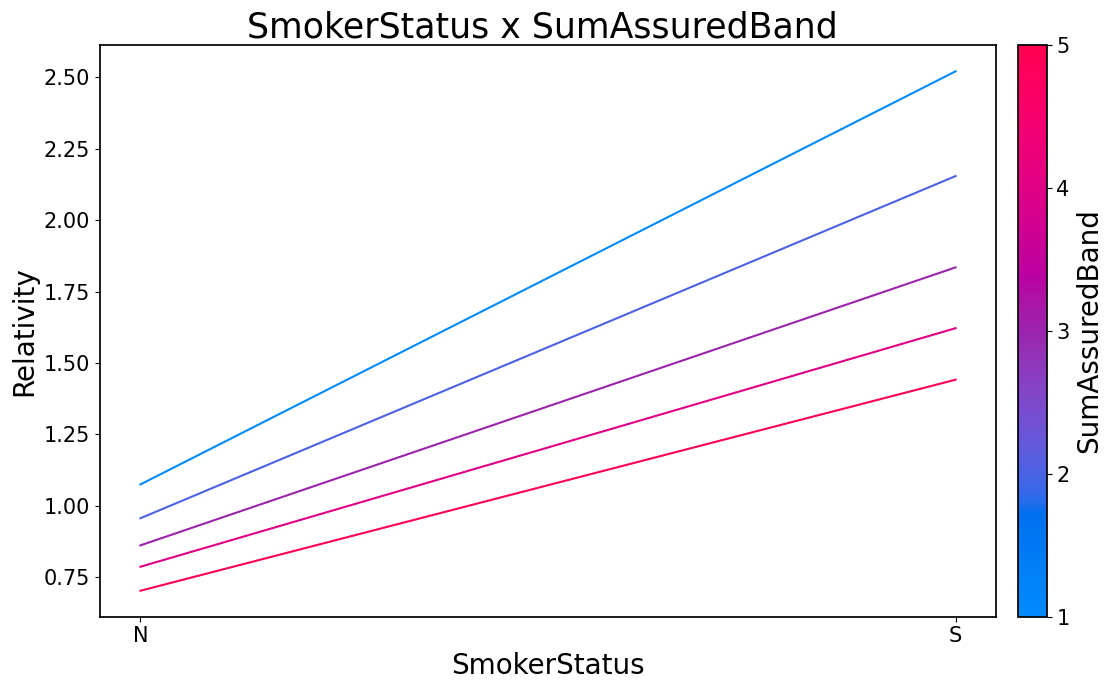

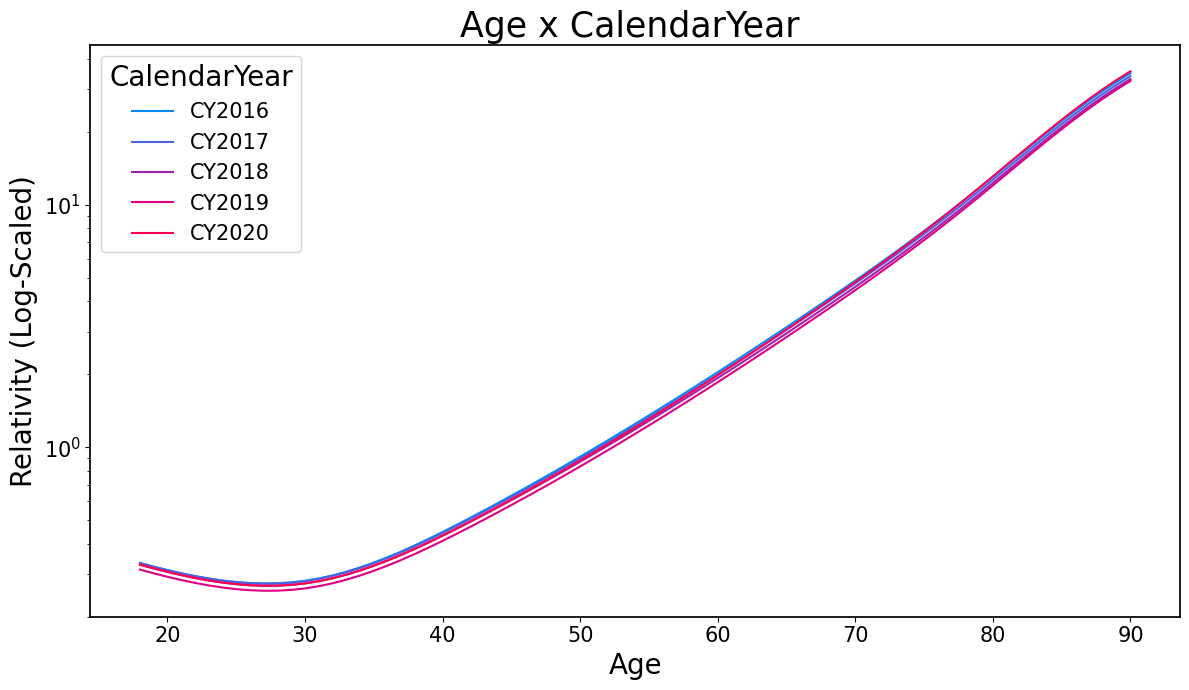

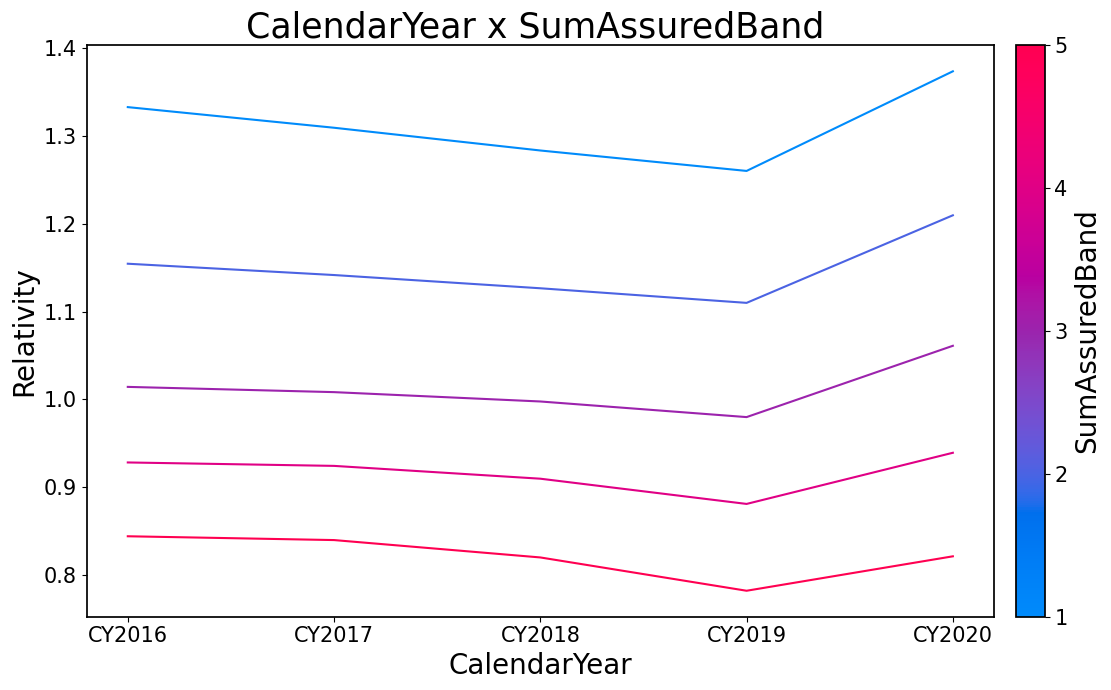

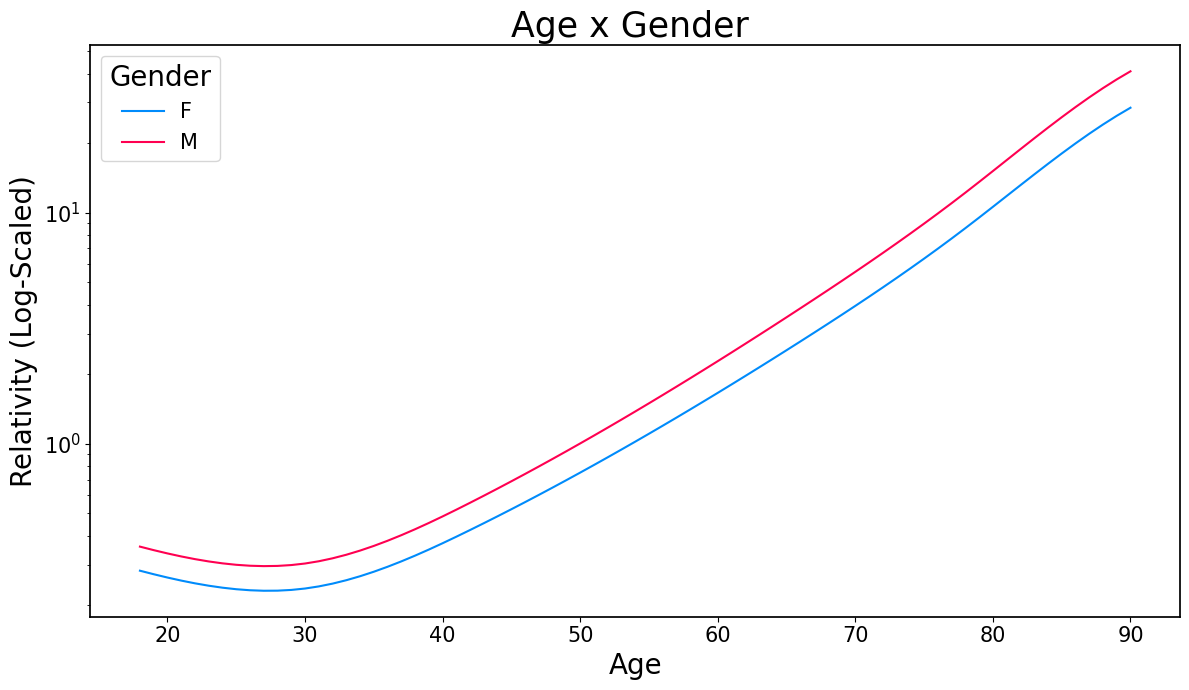

In [131]:
#################################################################
#################################################################

value_col = "combined_rel"
cmap = red_blue  
age_var = "Age"
title_suffix = ""
reverse_order_list = []
full_sec_var_list = []

#################################################################
#################################################################

cat_feat_clean = [x.replace("_cat_level", "") for x in cat_feat]

for k in interaction_df["interaction2"]:

    v1 = k.split(" x ")[0]
    v1 += "_cat_level" if v1 in cat_feat_clean else ""
    v2 = k.split(" x ")[1]
    v2 += "_cat_level" if v2 in cat_feat_clean else ""
    v1_clean = v1.replace("_cat_level", "")
    v2_clean = v2.replace("_cat_level", "")

    v = inter_rel_dict2[v1 + " x " + v2]

    if k in reverse_order_list:
        primary_var = v2
        secondary_var = v1
        primary_var_clean = v2_clean
        secondary_var_clean = v1_clean
    else:
        primary_var = v1
        secondary_var = v2
        primary_var_clean = v1_clean
        secondary_var_clean = v2_clean

    rel_wide = v.sort_values([primary_var_clean, secondary_var_clean]).pivot(
        index=primary_var_clean, columns=secondary_var_clean, values=value_col
    )

    # Clean column names
    rel_wide.columns = [
        c if (isinstance(c, str) or c != int(c)) else int(c) for c in rel_wide.columns
    ]

    fig, ax = plt.subplots(1, figsize=(12, 7))

    # Handle both numeric and categorical columns
    col_labels = rel_wide.columns.tolist()

    try:
        vmin = float(rel_wide.columns.min())
        vmax = float(rel_wide.columns.max())
        col_values = rel_wide.columns
        is_categorical = False
    except (ValueError, TypeError):
        vmin = 0
        vmax = len(col_labels) - 1
        col_values = np.arange(len(col_labels))
        is_categorical = True

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Plot each line with colour mapped to column value/index
    for i, col in enumerate(rel_wide.columns):
        color = cmap(norm(col_values[i]))
        ax.plot(rel_wide.index, rel_wide[col], color=color, linewidth=1.5, label=col)

    if primary_var == age_var:
        ax.set_yscale("log")
        leftylabel = "Relativity (Log-Scaled)"
    else:
        leftylabel = "Relativity"

    ax.set_xlabel(primary_var_clean, fontsize=label_fontsize)
    ax.set_ylabel(leftylabel, fontsize=label_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)

    ax.set_title(
        f"{primary_var_clean.replace('_ordinal', '')} x {secondary_var_clean.replace('_ordinal', '')} {title_suffix}",
        fontsize=title_fontsize,
    )

    # Add colorbar or legend
    if is_categorical:
        ax.legend(
            title=secondary_var_clean.replace("_ordinal", ""),
            fontsize=ticker_fontsize,
            title_fontsize=label_fontsize,
            facecolor="white",
        )
    else:
        # Add colorbar
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label(
            secondary_var_clean.replace("_ordinal", ""), fontsize=label_fontsize
        )

        # Set colorbar ticks
        if is_categorical:
            tick_locs = col_values
            tick_labels = col_labels
            cbar.set_ticks(tick_locs)
            cbar.set_ticklabels(tick_labels)

        elif np.issubdtype(col_values.dtype, np.integer):
            ticks = np.arange(col_values.min(), col_values.max() + 1)
            if len(ticks) > 10:
                step = len(ticks) // 8
                ticks = ticks[::step]
            cbar.set_ticks(ticks)

            if secondary_var_clean == "Duration":
                tick_labels = [str(int(t)) for t in ticks]
                tick_labels[-1] = f"{int(ticks[-1])}+"
                cbar.set_ticklabels(tick_labels)

        cbar.ax.tick_params(labelsize=ticker_fontsize)

    if primary_var_clean in full_sec_var_list:
        xticks = rel_wide.index.values
        if len(xticks) > 10:
            step = len(xticks) // 8
            xticks = xticks[::step]
        ax.set_xticks(xticks)

    ax.grid(False)
    ax.set_facecolor("white")

    plt.tight_layout()

### Actual vs Expected Analysis on Holdout

In [134]:
##################################################################
##################################################################

key_features = [x.replace("_ordinal", "") for x in single_fact_df["feature"]]

##################################################################
##################################################################

# Initialise an empty dict for holding the grouped by dataframes
risk_agg_dict = {}


for v in key_features:
    # Perform risk aggregations by individual features
    df_gb = utils.risk_agg(
        ypred_test_df.join(model_data[key_features]),
        v,
        weight,
        claim_count,
        cmi_death_count=cmi_base,
        gam_death_count=new_model_count,
    )
    # We're doing Actual vs Expected analysis
    df_gb["cmi_death_rate"] = df_gb["actual_death_rate"] / df_gb["cmi_death_rate"]
    df_gb["gam_death_rate"] = df_gb["actual_death_rate"] / df_gb["gam_death_rate"]

    risk_agg_dict[v] = df_gb

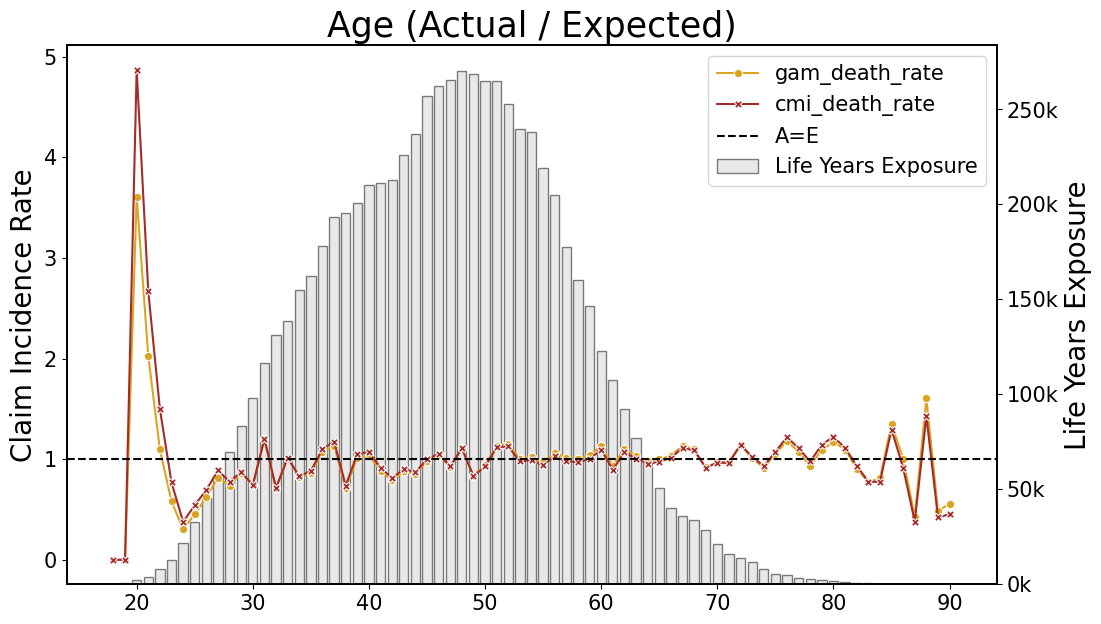

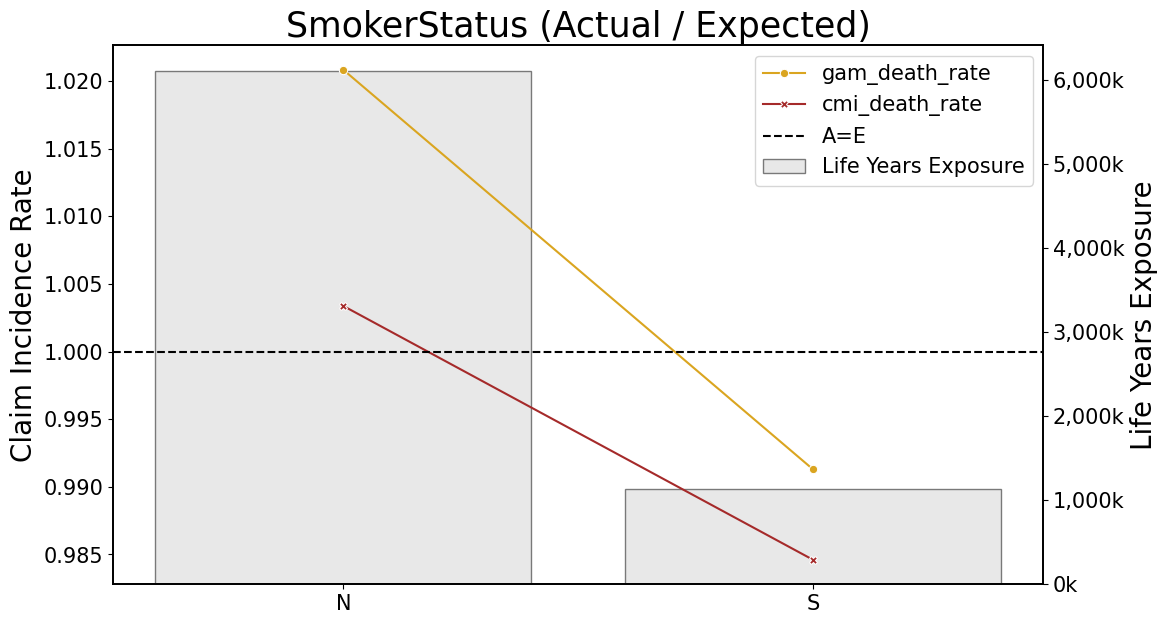

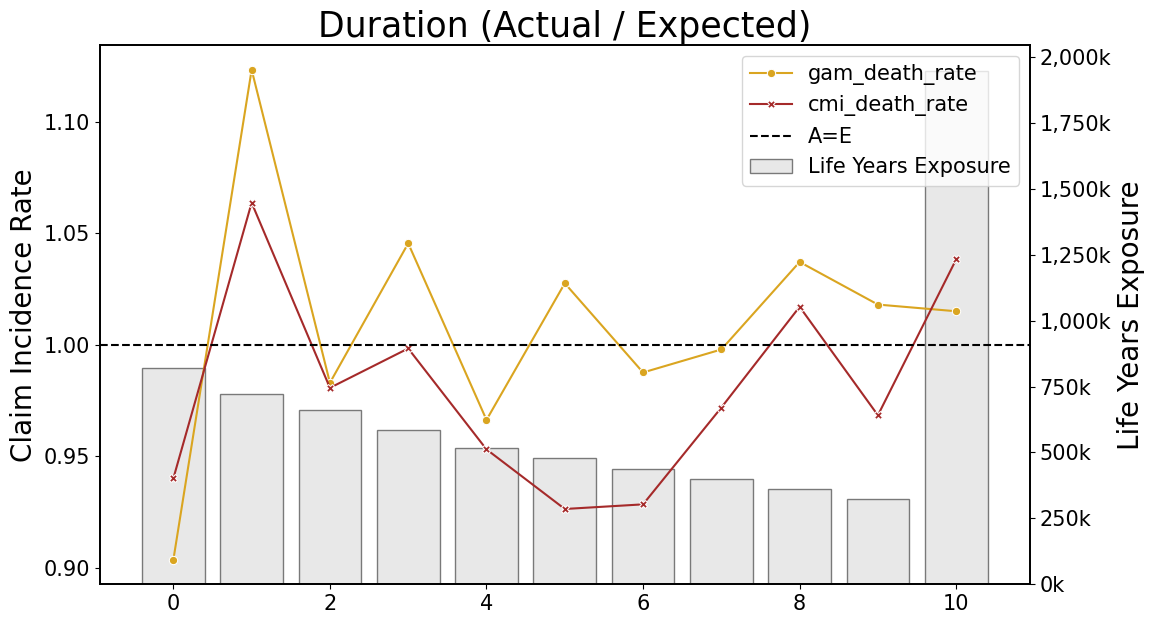

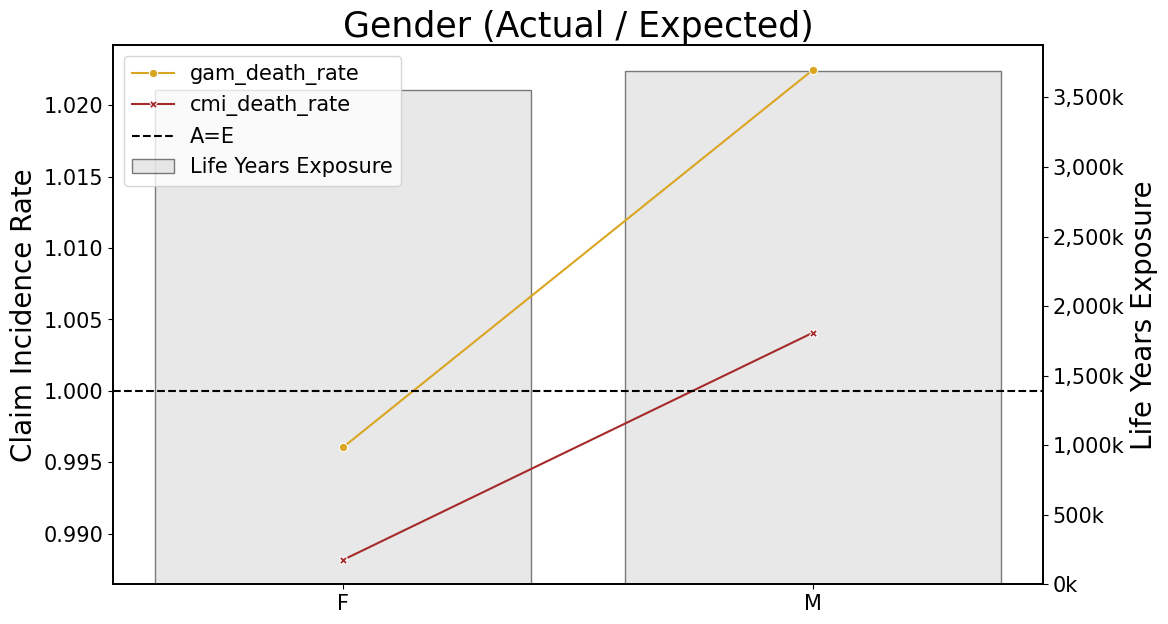

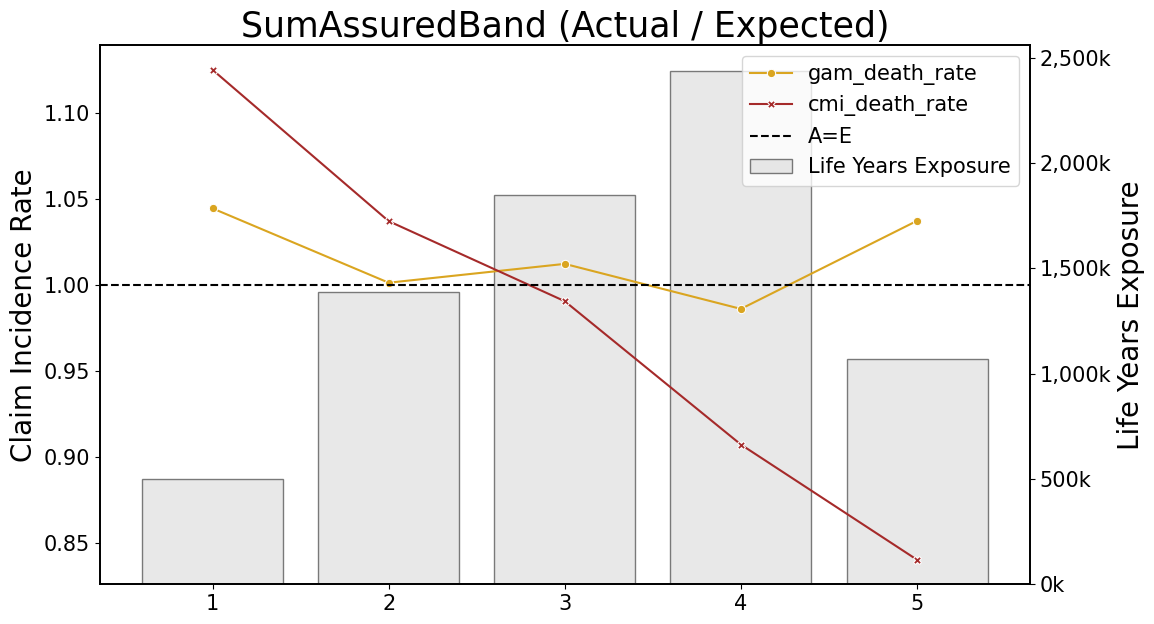

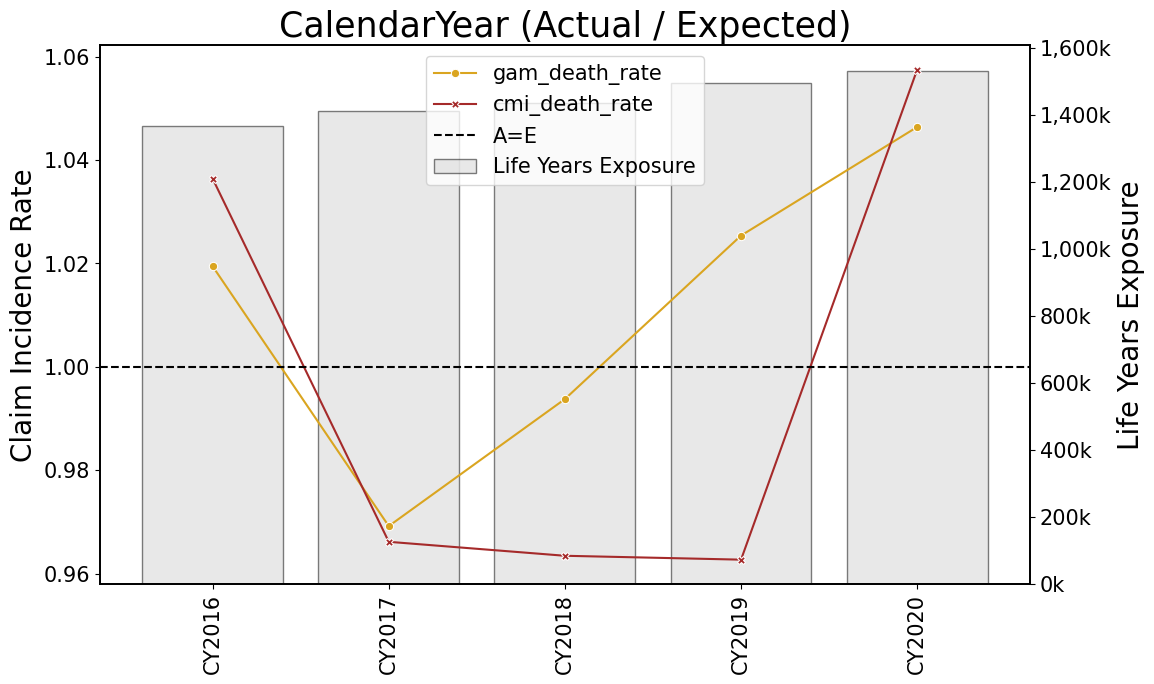

In [135]:
##############################################################################################
##############################################################################################

y1_label = "Claim Incidence Rate"
y2_label = "Life Years Exposure"

##############################################################################################
##############################################################################################

for var in key_features:

    fig, ax = plt.subplots(1, figsize=(12, 7))
    # Plot incidence rates
    sns.lineplot(
        data=risk_agg_dict[var].loc[
            :, ["gam_death_rate", "cmi_death_rate"]
        ],
        ax=ax,
        markers=True,
        dashes=False,
        palette=["#DAA520", "#A52A2A"],
    )
    ax.axhline(y=1, color="black", linestyle="--", label="A=E")

    # Set title and x and y axes labels and fontsize
    ax.set_ylabel(y1_label, fontsize=label_fontsize)
    ax.set_xlabel("")
    ax.set_title(var + " (Actual / Expected)", fontsize=title_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)

    # Fix the xticker labels if there are decimal places in xtickers when variable should be integers
    if not isinstance(risk_agg_dict[var].index[0], str):
        index_has_decimals = any(val % 1 != 0 for val in risk_agg_dict[var].index)
        ticks_have_decimals = any(tick % 1 != 0 for tick in ax.get_xticks())

        if not index_has_decimals and ticks_have_decimals:
            ax.set_xticks(risk_agg_dict[var].index)
            ax.set_xticklabels(risk_agg_dict[var].index)

    # Format x-axis tickers
    ax.tick_params(
        axis="x",
        rotation=(
            90
            if isinstance(risk_agg_dict[var].index[0], str)
            and len(risk_agg_dict[var].index[0]) > 4
            else 0
        ),
    )

    # Create secondary y-axis for exposures
    ax2 = ax.twinx()
    ax2.bar(
        risk_agg_dict[var].index,
        risk_agg_dict[var][weight],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=y2_label,
    )

    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=ticker_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=ticker_fontsize,
        facecolor="white",
    )

    # Set secondary y-axis label
    ax2.set_ylabel(y2_label, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)
    ax.grid(False)